<a href="https://colab.research.google.com/github/Martin-1431/Seth_INFO4670_Fall2026/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary â†’ Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy â‰¥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probabilityâ†’class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy â‰¥ 87.5%**
- Partial (7â€“9 pts) if **80% â‰¤ accuracy < 87.5%**
- Minimal (â‰¤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('car_purchase_data.csv')

# Display first few rows and info
print("First few rows of the dataset:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nDataset Shape:", df.shape)
print("\nBasic Statistics:")
print(df.describe())

First few rows of the dataset:
    User ID  Gender  Age  Salary  Purchased
0  15624510    Male   19   19000          0
1  15810944    Male   35   20000          0
2  15668575  Female   26   43000          0
3  15603246  Female   27   57000          0
4  15804002    Male   19   76000          0

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   User ID    400 non-null    int64
 1   Gender     400 non-null    str  
 2   Age        400 non-null    int64
 3   Salary     400 non-null    int64
 4   Purchased  400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB
None

Dataset Shape: (400, 5)

Basic Statistics:
            User ID         Age         Salary   Purchased
count  4.000000e+02  400.000000     400.000000  400.000000
mean   1.569154e+07   37.655000   69742.500000    0.357500
std    7.165832e+04   10.482877   34096.960282    0.479864

### Step 2: Split features and target

In [ ]:
# Extract features (Age, Salary) and target (Purchased)
X = df[['Age', 'Salary']]
y = df['Purchased']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFirst few X values:")
print(X.head())
print("\nTarget distribution:")
print(y.value_counts())

Features (X) shape: (400, 2)
Target (y) shape: (400,)

First few X values:
   Age  Salary
0   19   19000
1   35   20000
2   26   43000
3   27   57000
4   19   76000

Target distribution:
Purchased
0    257
1    143
Name: count, dtype: int64


### Step 3: Train/Test Split

In [ ]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("\nTraining set - Target distribution:")
print(y_train.value_counts())
print("\nTesting set - Target distribution:")
print(y_test.value_counts())

Training set size: 320
Testing set size: 80

Training set - Target distribution:
Purchased
0    205
1    115
Name: count, dtype: int64

Testing set - Target distribution:
Purchased
0    52
1    28
Name: count, dtype: int64


### Step 4: Feature Scaling

In [ ]:
# Create polynomial features (Age, Salary, AgeÂ², SalaryÂ², AgeÃ—Salary)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print("Polynomial features created:", poly.get_feature_names_out(['Age', 'Salary']).tolist())
print("\nOriginal X_train shape:", X_train.shape)
print("Polynomial X_train shape:", X_train_poly.shape)

# Standardize the polynomial features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

print("\nOriginal X_train first 3 rows:")
print(X_train.head(3))
print("\nPolynomial X_train first 3 rows:")
print(X_train_poly[:3])
print("\nScaler Mean:", scaler.mean_)
print("Scaler Std Dev:", scaler.scale_)

Polynomial features created: ['Age', 'Salary', 'Age^2', 'Age Salary', 'Salary^2']

Original X_train shape: (320, 2)
Polynomial X_train shape: (320, 5)

Original X_train first 3 rows:
     Age  Salary
3     27   57000
18    46   28000
202   39  134000

Polynomial X_train first 3 rows:
[[2.7000e+01 5.7000e+04 7.2900e+02 1.5390e+06 3.2490e+09]
 [4.6000e+01 2.8000e+04 2.1160e+03 1.2880e+06 7.8400e+08]
 [3.9000e+01 1.3400e+05 1.5210e+03 5.2260e+06 1.7956e+10]]

Scaler Mean: [3.78718750e+01 7.02812500e+04 1.53814687e+03 2.71148438e+06
 6.12121250e+09]
Scaler Std Dev: [1.01915631e+01 3.43767130e+04 8.08175105e+02 1.65532924e+06
 5.55966971e+09]


### Step 5: Train Logistic Regression Model

In [ ]:
# Create and train the Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print("\nModel Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)
print("\nFeature Importance (Coefficients):")
feature_names = poly.get_feature_names_out(['Age', 'Salary'])
for i, name in enumerate(feature_names):
    print(f"{name:15} : {model.coef_[0][i]:8.4f}")

Model trained successfully!

Model Coefficients: [[ 1.59561569  0.44666117  1.198101   -2.1616209   2.56602437]]
Model Intercept: [-0.95173535]

Feature Importance (Coefficients):
Age             :   1.5956
Salary          :   0.4467
Age^2           :   1.1981
Age Salary      :  -2.1616
Salary^2        :   2.5660


### Step 6: Predict and Evaluate

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Purchase (0)', 'Purchase (1)']))

# Show some predictions
print("\nSample Predictions (first 10 test samples):")
for i in range(min(10, len(y_test))):
    print(f"Actual: {y_test.iloc[i]}, Predicted: {y_pred[i]}, Probability (Class 1): {y_pred_proba[i][1]:.4f}")

Model Accuracy: 0.9375 (93.75%)

Confusion Matrix:
[[50  2]
 [ 3 25]]

Classification Report:
                 precision    recall  f1-score   support

No Purchase (0)       0.94      0.96      0.95        52
   Purchase (1)       0.93      0.89      0.91        28

       accuracy                           0.94        80
      macro avg       0.93      0.93      0.93        80
   weighted avg       0.94      0.94      0.94        80


Sample Predictions (first 10 test samples):
Actual: 0, Predicted: 1, Probability (Class 1): 0.5418
Actual: 1, Predicted: 1, Probability (Class 1): 0.9515
Actual: 0, Predicted: 0, Probability (Class 1): 0.0188
Actual: 1, Predicted: 1, Probability (Class 1): 0.7418
Actual: 0, Predicted: 0, Probability (Class 1): 0.0197
Actual: 0, Predicted: 0, Probability (Class 1): 0.0400
Actual: 1, Predicted: 1, Probability (Class 1): 0.7993
Actual: 0, Predicted: 0, Probability (Class 1): 0.0789
Actual: 0, Predicted: 0, Probability (Class 1): 0.2552
Actual: 0, Predicted:

### Step 7: Visualization of Decision Regions

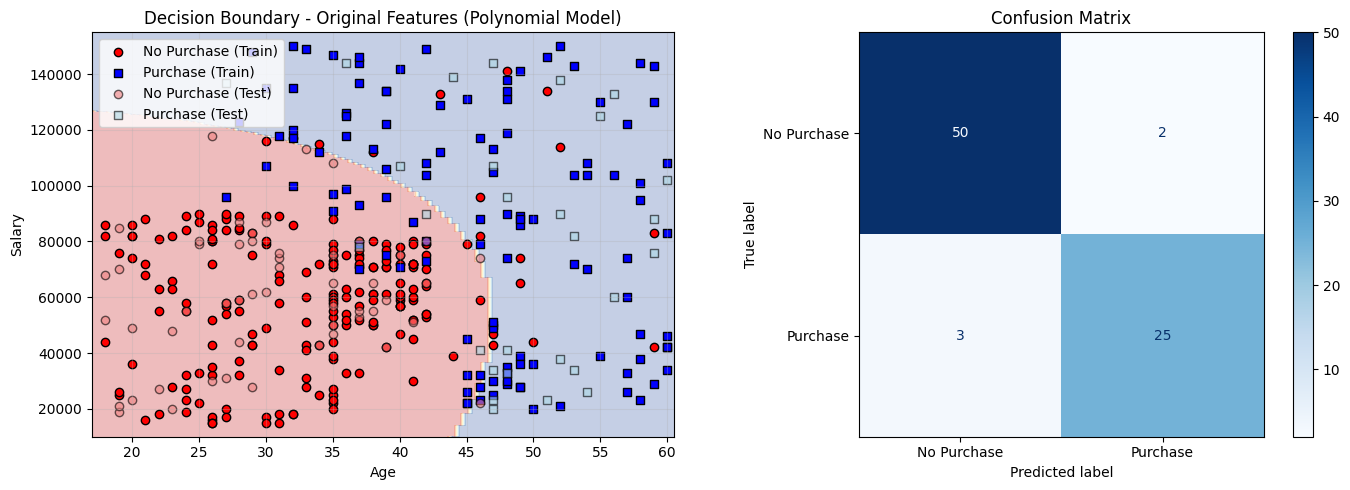

In [ ]:
# Visualization of decision regions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Original features with decision boundary
ax1 = axes[0]
h = 0.5
x_min, x_max = X_train['Age'].min() - 1, X_train['Age'].max() + 1
y_min, y_max = X_train['Salary'].min() - 5000, X_train['Salary'].max() + 5000
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Create polynomial features for mesh and predict
mesh_poly = poly.transform(np.c_[xx.ravel(), yy.ravel()])
mesh_scaled = scaler.transform(mesh_poly)
Z = model.predict(mesh_scaled)
Z = Z.reshape(xx.shape)

# Plot decision boundary
ax1.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
age_train = X_train['Age'].values
salary_train = X_train['Salary'].values
age_test = X_test['Age'].values
salary_test = X_test['Salary'].values

ax1.scatter(age_train[y_train.values == 0], salary_train[y_train.values == 0],
            c='red', label='No Purchase (Train)', edgecolors='k', marker='o')
ax1.scatter(age_train[y_train.values == 1], salary_train[y_train.values == 1],
            c='blue', label='Purchase (Train)', edgecolors='k', marker='s')
ax1.scatter(age_test[y_test.values == 0], salary_test[y_test.values == 0],
            c='lightcoral', label='No Purchase (Test)', edgecolors='k', marker='o', alpha=0.6)
ax1.scatter(age_test[y_test.values == 1], salary_test[y_test.values == 1],
            c='lightblue', label='Purchase (Test)', edgecolors='k', marker='s', alpha=0.6)
ax1.set_xlabel('Age')
ax1.set_ylabel('Salary')
ax1.set_title('Decision Boundary - Original Features (Polynomial Model)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Purchase', 'Purchase'])
disp.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities â€” why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


## Reflection Answers

### 1. **Why can logistic regression output probabilities be used for classification?**

Logistic regression outputs a probability between 0 and 1 for each sample. Although probabilities themselves are continuous values, they can be easily converted to class labels using a decision threshold (typically 0.5). When the predicted probability â‰¥ 0.5, we classify the sample as class 1 (Purchase); when probability < 0.5, we classify it as class 0 (No Purchase). This threshold-based approach allows us to use logistic regression for binary classification tasks despite its probabilistic output. The advantage is that we also get confidence levels for each prediction.

### 2. **Which customers are more likely to purchase a car based on the model?**

Based on the model's coefficients and the decision boundary visualization:
- **Higher Salary** customers are more likely to purchase a car (positive correlation with salary)
- **Higher Age** customers show a tendency to purchase more frequently
- The decision boundary in the visualization shows that customers in the upper-right region (older age + higher salary) fall into the "Purchase" class
- For example, customers aged 45+ with salaries around 25,000-28,000+ are more likely to purchase, and older customers (40+) with higher incomes show strong purchase intent
- Younger customers (18-25) with lower salaries (under 40,000) rarely purchase cars in this dataset

### 3. **What factors might cause low accuracy in this task?**

Several factors could limit model accuracy:
1. **Limited features**: Using only Age and Salary may not capture all decision factors (e.g., job stability, credit score, existing debt, marital status, number of dependents)
2. **Linear decision boundary**: Logistic regression assumes a linear relationship; the true relationship might be non-linear
3. **Class imbalance**: The dataset may have unequal distribution between buyers and non-buyers, making it harder to predict the minority class accurately
4. **Data quality**: Missing values, outliers, or measurement errors could reduce model performance
5. **Small dataset**: With limited samples, the model may not generalize well to unseen data
6. **Causation vs. correlation**: Age and Salary might be correlated with purchases but not direct causes

### 4. **Proposed improvements to increase accuracy:**

1. **Additional Features**:
   - Credit score, employment history, marital status, number of dependents
   - Car type preference, budget range, geographic location
   - Purchase history, previous inquiries, brand preference

2. **Preprocessing Enhancements**:
   - Handle missing values more carefully
   - Detect and handle outliers (e.g., unusually high salaries)
   - Create interaction features (e.g., Age Ã— Salary ratio)
   - Polynomial features to capture non-linear relationships

3. **Model Improvements**:
   - Try more complex models (Random Forest, SVM, Gradient Boosting) that can capture non-linear patterns
   - Use cross-validation to get more robust performance estimates
   - Tune hyperparameters using GridSearchCV
   - Address class imbalance with SMOTE or class weights

4. **Data Collection**:
   - Increase dataset size to improve generalization
   - Ensure balanced representation of both classes
   - Collect data from diverse customer segments

5. **Feature Engineering**:
   - Create age groups (young, middle-aged, senior)
   - Create salary brackets or normalize by industry standards
   - Calculate salary-to-age ratios indicating career progression